In [1]:
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from knnbench.functions_to_use import *

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
os.makedirs("results", exist_ok=True)

In this cell, we're doing manual grid search over a variety of seeds and k values to get reliable estimates of metrics to compare with our implementations

In [2]:
import pandas as pd
import numpy as np
 
seeds = [42, 123, 456, 789, 1024]
ks = [3, 4, 5, 7, 8, 9, 11, 12, 15, 21]
 
# --- Manual grid across seeds ---
all_manual = []
for s in seeds:
    print(f"Running manual grid with seed={s}...")
    rows = run_manual_grid_adult(
        ks=ks,
        scalings=[None, "standard", "minmax"],
        votings=["uniform", "distance"],
        tie_breaks=["nearest", "min_class"],
        seed=s,
        batch_size=512,
        include_ties=True,
    )
    for r in rows:
        r["seed"] = s
    all_manual.extend(rows)
    print(f"  Done. ({len(rows)} configs)")
 
df_manual_all = pd.DataFrame(all_manual)
print(f"\nTotal manual rows: {len(df_manual_all)}")
 
# --- Sklearn grid across seeds ---
all_sklearn = []
for s in seeds:
    print(f"Running sklearn grid with seed={s}...")
    rows = run_sklearn_grid_adult(
        ks=ks,
        scalings=[None, "standard", "minmax"],
        weights_list=["uniform", "distance"],
        seed=s,
    )
    for r in rows:
        r["seed"] = s
    all_sklearn.extend(rows)
    print(f"  Done. ({len(rows)} configs)")
 
df_sklearn_all = pd.DataFrame(all_sklearn)
print(f"\nTotal sklearn rows: {len(df_sklearn_all)}")
 
# --- Aggregate: mean and std across seeds ---
group_cols_manual = ["k", "scaling", "weights", "tie_break"]
df_manual_agg = df_manual_all.groupby(group_cols_manual, dropna=False).agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_std=("macro_f1", "std"),
    macro_recall_mean=("macro_recall", "mean"),
    macro_recall_std=("macro_recall", "std"),
    macro_precision_mean=("macro_precision", "mean"),
    macro_precision_std=("macro_precision", "std"),
    ties_mean=("ties", "mean"),
    ties_std=("ties", "std"),
).reset_index()
 
group_cols_sklearn = ["k", "scaling", "weights"]
df_sklearn_agg = df_sklearn_all.groupby(group_cols_sklearn, dropna=False).agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_std=("macro_f1", "std"),
    macro_recall_mean=("macro_recall", "mean"),
    macro_recall_std=("macro_recall", "std"),
    macro_precision_mean=("macro_precision", "mean"),
    macro_precision_std=("macro_precision", "std"),
).reset_index()
 
print("Aggregation done.")
print(f"Manual configs: {len(df_manual_agg)}")
print(f"Sklearn configs: {len(df_sklearn_agg)}")

Running manual grid with seed=42...
  Done. (120 configs)
Running manual grid with seed=123...
  Done. (120 configs)
Running manual grid with seed=456...
  Done. (120 configs)
Running manual grid with seed=789...
  Done. (120 configs)
Running manual grid with seed=1024...
  Done. (120 configs)

Total manual rows: 600
Running sklearn grid with seed=42...
  Done. (60 configs)
Running sklearn grid with seed=123...
  Done. (60 configs)
Running sklearn grid with seed=456...
  Done. (60 configs)
Running sklearn grid with seed=789...
  Done. (60 configs)
Running sklearn grid with seed=1024...
  Done. (60 configs)

Total sklearn rows: 300
Aggregation done.
Manual configs: 120
Sklearn configs: 60


In this cell, the majority baseline function is run on all seeds

In [3]:
majority_results = []
for s in seeds:
    res = run_majority_baseline_adult(seed=s)
    majority_results.append(res["val"])
 
majority_f1_mean = np.mean([r["macro_f1"] for r in majority_results])
majority_f1_std = np.std([r["macro_f1"] for r in majority_results])
majority_acc_mean = np.mean([r["accuracy"] for r in majority_results])
 
print(f"Majority baseline (val): accuracy={majority_acc_mean:.4f}, "
      f"macro_f1={majority_f1_mean:.4f} ± {majority_f1_std:.4f}")

c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maxi

Majority baseline (val): accuracy=0.7608, macro_f1=0.4321 ± 0.0000


c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In this cell, impacts of scaling is shown for macro F1 in a graph

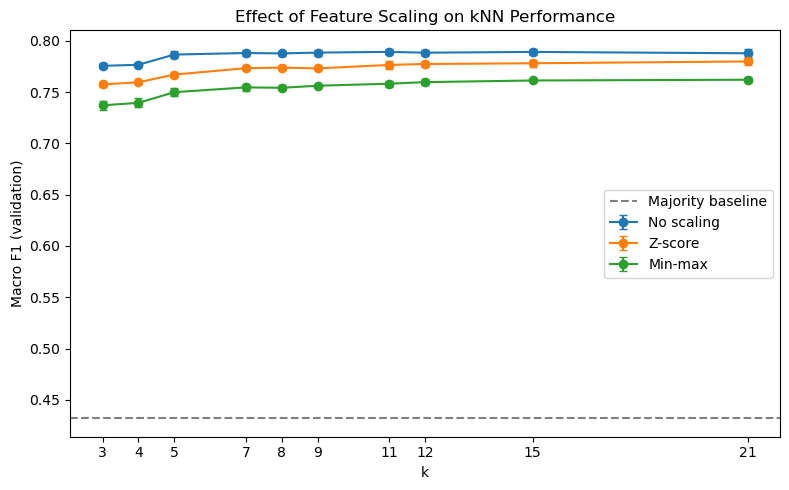

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
 
subset = df_manual_agg[
    (df_manual_agg["weights"] == "uniform") &
    (df_manual_agg["tie_break"] == "nearest")
]
 
scaling_labels = {None: "No scaling", "standard": "Z-score", "minmax": "Min-max"}
# Handle NaN scaling (None becomes NaN in pandas groupby)
for scaling_val in [None, "standard", "minmax"]:
    if scaling_val is None:
        data = subset[subset["scaling"].isna()]
    else:
        data = subset[subset["scaling"] == scaling_val]
    data = data.sort_values("k")
    label = scaling_labels[scaling_val]
    ax.errorbar(
        data["k"], data["macro_f1_mean"], yerr=data["macro_f1_std"],
        marker="o", capsize=3, label=label
    )
 
ax.axhline(y=majority_f1_mean, color="gray", linestyle="--", label="Majority baseline")
ax.set_xlabel("k")
ax.set_ylabel("Macro F1 (validation)")
ax.set_title("Effect of Feature Scaling on kNN Performance")
ax.legend()
ax.set_xticks(ks)
plt.tight_layout()
plt.savefig("results/fig1_scaling_effect.png", dpi=150)
plt.show()

In this cell, impacts of voting is shown for macro F1 in a graph

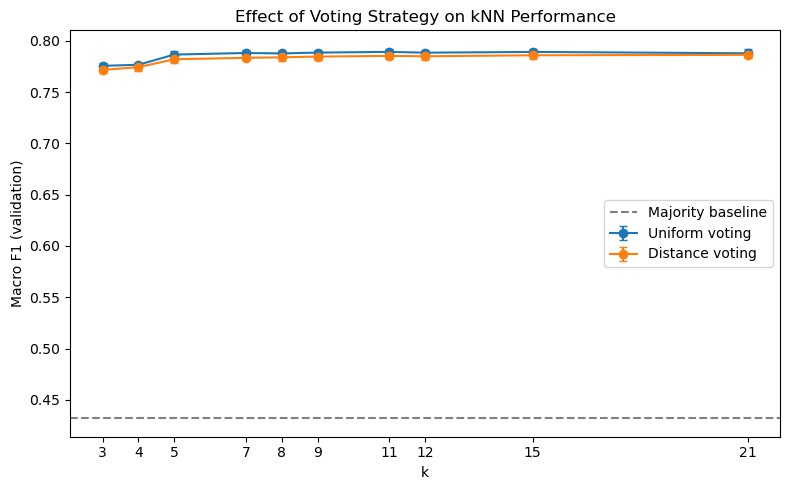

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
 
subset = df_manual_agg[
    (df_manual_agg["scaling"].isna()) &
    (df_manual_agg["tie_break"] == "nearest")
]
 
for voting in ["uniform", "distance"]:
    data = subset[subset["weights"] == voting].sort_values("k")
    ax.errorbar(
        data["k"], data["macro_f1_mean"], yerr=data["macro_f1_std"],
        marker="o", capsize=3, label=f"{voting.capitalize()} voting"
    )
 
ax.axhline(y=majority_f1_mean, color="gray", linestyle="--", label="Majority baseline")
ax.set_xlabel("k")
ax.set_ylabel("Macro F1 (validation)")
ax.set_title("Effect of Voting Strategy on kNN Performance")
ax.legend()
ax.set_xticks(ks)
plt.tight_layout()
plt.savefig("results/fig2_voting_effect.png", dpi=150)
plt.show()

In this cell we generate 2 charts, first on the left how many ties occur at each k value, and on the right whether the choice of tie-breaking strategy makes a difference to the F1 score

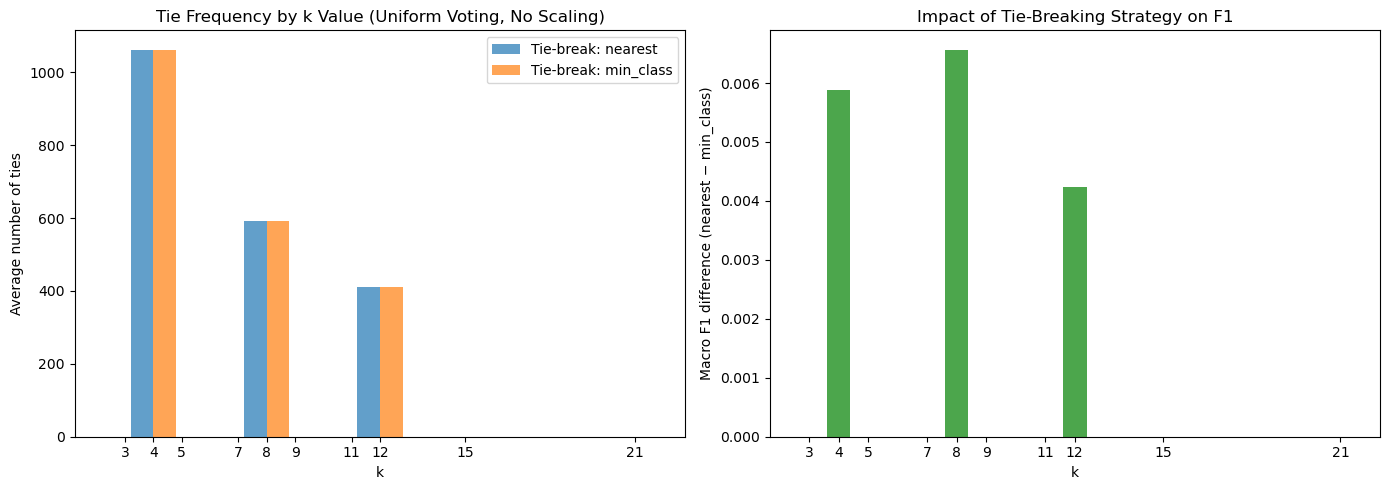

In [6]:
# First, let's see where ties actually matter (even k, uniform voting)
even_ks = [k for k in ks if k % 2 == 0]
 
# If your k list has no even values, use all k and filter by ties > 0
# For odd k there are typically very few ties, so show the contrast
 
# Show tie counts and F1 difference for uniform voting, no scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: Average number of ties by k and tie-break method
subset_ties = df_manual_agg[
    (df_manual_agg["scaling"].isna()) &
    (df_manual_agg["weights"] == "uniform")
].sort_values("k")
 
for tb in ["nearest", "min_class"]:
    data = subset_ties[subset_ties["tie_break"] == tb].sort_values("k")
    ax1.bar(
        data["k"].values + (-0.4 if tb == "nearest" else 0.4),
        data["ties_mean"],
        width=0.8,
        label=f"Tie-break: {tb}",
        alpha=0.7,
    )
 
ax1.set_xlabel("k")
ax1.set_ylabel("Average number of ties")
ax1.set_title("Tie Frequency by k Value (Uniform Voting, No Scaling)")
ax1.legend()
ax1.set_xticks(ks)
 
# Right: F1 difference (nearest - min_class) by k
nearest_data = subset_ties[subset_ties["tie_break"] == "nearest"].sort_values("k")
minclass_data = subset_ties[subset_ties["tie_break"] == "min_class"].sort_values("k")
 
# Merge on k
merged = nearest_data[["k", "macro_f1_mean"]].merge(
    minclass_data[["k", "macro_f1_mean"]],
    on="k", suffixes=("_nearest", "_minclass")
)
merged["f1_diff"] = merged["macro_f1_mean_nearest"] - merged["macro_f1_mean_minclass"]
 
colors = ["green" if d >= 0 else "red" for d in merged["f1_diff"]]
ax2.bar(merged["k"], merged["f1_diff"], color=colors, alpha=0.7)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.set_xlabel("k")
ax2.set_ylabel("Macro F1 difference (nearest − min_class)")
ax2.set_title("Impact of Tie-Breaking Strategy on F1")
ax2.set_xticks(ks)
 
plt.tight_layout()
plt.savefig("results/fig3_tiebreaking_effect.png", dpi=150)
plt.show()

In this cell, baseline, main and sklearn KNN are compared on F1 scores

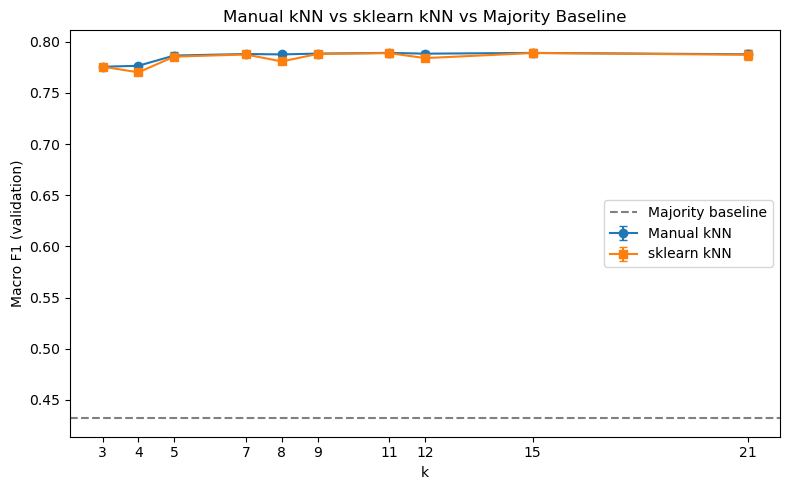

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
 
# Manual: no scaling, uniform, nearest
manual_best = df_manual_agg[
    (df_manual_agg["scaling"].isna()) &
    (df_manual_agg["weights"] == "uniform") &
    (df_manual_agg["tie_break"] == "nearest")
].sort_values("k")
 
ax.errorbar(
    manual_best["k"], manual_best["macro_f1_mean"], yerr=manual_best["macro_f1_std"],
    marker="o", capsize=3, label="Manual kNN"
)
 
# Sklearn: no scaling, uniform (closest comparison)
sklearn_best = df_sklearn_agg[
    (df_sklearn_agg["scaling"].isna()) &
    (df_sklearn_agg["weights"] == "uniform")
].sort_values("k")
 
ax.errorbar(
    sklearn_best["k"], sklearn_best["macro_f1_mean"], yerr=sklearn_best["macro_f1_std"],
    marker="s", capsize=3, label="sklearn kNN"
)
 
# Majority baseline
ax.axhline(y=majority_f1_mean, color="gray", linestyle="--", label="Majority baseline")
 
ax.set_xlabel("k")
ax.set_ylabel("Macro F1 (validation)")
ax.set_title("Manual kNN vs sklearn kNN vs Majority Baseline")
ax.legend()
ax.set_xticks(ks)
plt.tight_layout()
plt.savefig("results/fig4_baseline_comparison.png", dpi=150)
plt.show()

In this cell, best configurations displayed with optimal parameters

In [8]:
best_row = df_manual_agg.loc[df_manual_agg["macro_f1_mean"].idxmax()]
print("Best manual config on validation (averaged across seeds):")
print(f"  k={int(best_row['k'])}, scaling={best_row['scaling']}, "
      f"weights={best_row['weights']}, tie_break={best_row['tie_break']}")
print(f"  macro_f1 = {best_row['macro_f1_mean']:.4f} ± {best_row['macro_f1_std']:.4f}")
print()
 
# Run best config on test across seeds
best_scaling = best_row["scaling"] if pd.notna(best_row["scaling"]) else None
test_results = []
for s in seeds:
    res = run_manual_best_on_test_adult(
        k=int(best_row["k"]),
        scaling=best_scaling,
        voting=best_row["weights"],
        tie_break=best_row["tie_break"],
        seed=s,
    )
    test_results.append(res)
 
test_f1s = [r["macro_f1"] for r in test_results]
test_accs = [r["accuracy"] for r in test_results]
 
print("Test set results (across seeds):")
print(f"  accuracy = {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
print(f"  macro_f1 = {np.mean(test_f1s):.4f} ± {np.std(test_f1s):.4f}")
print()
 
# Also run sklearn best on test for comparison
best_sk_row = df_sklearn_agg.loc[df_sklearn_agg["macro_f1_mean"].idxmax()]
best_sk_scaling = best_sk_row["scaling"] if pd.notna(best_sk_row["scaling"]) else None
sk_test_results = []
for s in seeds:
    res = run_sklearn_best_on_test_adult(
        k=int(best_sk_row["k"]),
        scaling=best_sk_scaling,
        weights=best_sk_row["weights"],
        seed=s,
    )
    sk_test_results.append(res)
 
sk_test_f1s = [r["macro_f1"] for r in sk_test_results]
sk_test_accs = [r["accuracy"] for r in sk_test_results]
 
print("Best sklearn config on test (across seeds):")
print(f"  k={int(best_sk_row['k'])}, scaling={best_sk_scaling}, weights={best_sk_row['weights']}")
print(f"  accuracy = {np.mean(sk_test_accs):.4f} ± {np.std(sk_test_accs):.4f}")
print(f"  macro_f1 = {np.mean(sk_test_f1s):.4f} ± {np.std(sk_test_f1s):.4f}")
print()
 
# Majority baseline on test
maj_test_results = []
for s in seeds:
    res = run_majority_baseline_adult(seed=s)
    maj_test_results.append(res["test"])
 
maj_test_f1s = [r["macro_f1"] for r in maj_test_results]
print("Majority baseline on test (across seeds):")
print(f"  macro_f1 = {np.mean(maj_test_f1s):.4f} ± {np.std(maj_test_f1s):.4f}")

Best manual config on validation (averaged across seeds):
  k=11, scaling=nan, weights=uniform, tie_break=min_class
  macro_f1 = 0.7892 ± 0.0024

Test set results (across seeds):
  accuracy = 0.8545 ± 0.0025
  macro_f1 = 0.7908 ± 0.0029

Best sklearn config on test (across seeds):
  k=15, scaling=None, weights=uniform
  accuracy = 0.8549 ± 0.0028
  macro_f1 = 0.7902 ± 0.0029



c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maxi

Majority baseline on test (across seeds):
  macro_f1 = 0.4320 ± 0.0000


c:\Users\maxim\anaconda3\envs\pbd\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best configurations displayed on a table with accuracy, precision, recall and F1 score shown to 4 significant digits 

In [9]:
# Collect all test results into a single table
summary_rows = []
 
# 1. Best manual config
manual_test_metrics = {
    "accuracy": np.mean([r["accuracy"] for r in test_results]),
    "macro_precision": np.mean([r["macro_precision"] for r in test_results]),
    "macro_recall": np.mean([r["macro_recall"] for r in test_results]),
    "macro_f1": np.mean([r["macro_f1"] for r in test_results]),
}
manual_test_stds = {
    "accuracy": np.std([r["accuracy"] for r in test_results]),
    "macro_precision": np.std([r["macro_precision"] for r in test_results]),
    "macro_recall": np.std([r["macro_recall"] for r in test_results]),
    "macro_f1": np.std([r["macro_f1"] for r in test_results]),
}
 
best_k = int(best_row["k"])
best_s = best_row["scaling"] if pd.notna(best_row["scaling"]) else "None"
best_v = best_row["weights"]
best_tb = best_row["tie_break"]
 
summary_rows.append({
    "Model": f"Manual kNN (k={best_k}, {best_s}, {best_v}, {best_tb})",
    "Accuracy": f"{manual_test_metrics['accuracy']:.4f} ± {manual_test_stds['accuracy']:.4f}",
    "Macro Precision": f"{manual_test_metrics['macro_precision']:.4f} ± {manual_test_stds['macro_precision']:.4f}",
    "Macro Recall": f"{manual_test_metrics['macro_recall']:.4f} ± {manual_test_stds['macro_recall']:.4f}",
    "Macro F1": f"{manual_test_metrics['macro_f1']:.4f} ± {manual_test_stds['macro_f1']:.4f}",
})
 
# 2. Best sklearn config
sk_test_metrics = {
    "accuracy": np.mean([r["accuracy"] for r in sk_test_results]),
    "macro_precision": np.mean([r["macro_precision"] for r in sk_test_results]),
    "macro_recall": np.mean([r["macro_recall"] for r in sk_test_results]),
    "macro_f1": np.mean([r["macro_f1"] for r in sk_test_results]),
}
sk_test_stds = {
    "accuracy": np.std([r["accuracy"] for r in sk_test_results]),
    "macro_precision": np.std([r["macro_precision"] for r in sk_test_results]),
    "macro_recall": np.std([r["macro_recall"] for r in sk_test_results]),
    "macro_f1": np.std([r["macro_f1"] for r in sk_test_results]),
}
 
sk_k = int(best_sk_row["k"])
sk_s = best_sk_row["scaling"] if pd.notna(best_sk_row["scaling"]) else "None"
sk_w = best_sk_row["weights"]
 
summary_rows.append({
    "Model": f"sklearn kNN (k={sk_k}, {sk_s}, {sk_w})",
    "Accuracy": f"{sk_test_metrics['accuracy']:.4f} ± {sk_test_stds['accuracy']:.4f}",
    "Macro Precision": f"{sk_test_metrics['macro_precision']:.4f} ± {sk_test_stds['macro_precision']:.4f}",
    "Macro Recall": f"{sk_test_metrics['macro_recall']:.4f} ± {sk_test_stds['macro_recall']:.4f}",
    "Macro F1": f"{sk_test_metrics['macro_f1']:.4f} ± {sk_test_stds['macro_f1']:.4f}",
})
 
# 3. Majority baseline
maj_test_metrics = {
    "accuracy": np.mean([r["accuracy"] for r in maj_test_results]),
    "macro_precision": np.mean([r["macro_precision"] for r in maj_test_results]),
    "macro_recall": np.mean([r["macro_recall"] for r in maj_test_results]),
    "macro_f1": np.mean([r["macro_f1"] for r in maj_test_results]),
}
maj_test_stds = {
    "accuracy": np.std([r["accuracy"] for r in maj_test_results]),
    "macro_precision": np.std([r["macro_precision"] for r in maj_test_results]),
    "macro_recall": np.std([r["macro_recall"] for r in maj_test_results]),
    "macro_f1": np.std([r["macro_f1"] for r in maj_test_results]),
}
 
summary_rows.append({
    "Model": "Majority baseline",
    "Accuracy": f"{maj_test_metrics['accuracy']:.4f} ± {maj_test_stds['accuracy']:.4f}",
    "Macro Precision": f"{maj_test_metrics['macro_precision']:.4f} ± {maj_test_stds['macro_precision']:.4f}",
    "Macro Recall": f"{maj_test_metrics['macro_recall']:.4f} ± {maj_test_stds['macro_recall']:.4f}",
    "Macro F1": f"{maj_test_metrics['macro_f1']:.4f} ± {maj_test_stds['macro_f1']:.4f}",
})
 
# Build and display the table
df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary.set_index("Model")
print("=" * 90)
print("SUMMARY TABLE: Test Set Performance (mean ± std across seeds)")
print("=" * 90)
print(df_summary.to_string())
print()
 
# Also save as CSV for easy copy-paste into LaTeX/Word later
df_summary.to_csv("results/summary_table.csv")
print("Saved to results/summary_table.csv")

SUMMARY TABLE: Test Set Performance (mean ± std across seeds)
                                                    Accuracy  Macro Precision     Macro Recall         Macro F1
Model                                                                                                          
Manual kNN (k=11, None, uniform, min_class)  0.8545 ± 0.0025  0.8068 ± 0.0047  0.7783 ± 0.0022  0.7908 ± 0.0029
sklearn kNN (k=15, None, uniform)            0.8549 ± 0.0028  0.8085 ± 0.0054  0.7763 ± 0.0014  0.7902 ± 0.0029
Majority baseline                            0.7607 ± 0.0000  0.3803 ± 0.0000  0.5000 ± 0.0000  0.4320 ± 0.0000

Saved to results/summary_table.csv
